In [47]:
import pandas as pd
import setup_paths as paths
import matplotlib.pyplot as plt
import numpy as np
import data_plotting_func_min_dist as data_plotting
import matplotlib
import numpy.ma as ma

In [2]:
filenames = ['eq_object_04s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
             'eq_object_41s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
			 'eq_object_06s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
			 'eq_object_11s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
             'eq_object_1s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
		 	 'eq_object_03s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
			 'eq_object_1s_snr_20_blank_01_reviews_snr_20_delay.pkl',
             'eq_object_03s_snr_20_blank_01_reviews_snr_20_delay.pkl',
	 		 'eq_object_4s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
			 'eq_object_05s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
			 'eq_object_4s_snr_20_blank_01_reviews_snr_20_delay.pkl',
			 'eq_object_05s_snr_20_blank_01_reviews_snr_20_delay.pkl']

In [24]:
paths.data_path

'/home/earthquakes1/homes/Rebecca/phd/seismo_det/code/../../data/'

In [27]:
filenames = ['eq_object_04s_snr_20_blank_01_reviews_snr_20_delay.pkl',
		 	 'eq_object_03s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl',
             'eq_object_03s_snr_20_blank_01_reviews_snr_20_delay.pkl']

min_dist = 0
max_dist = 200

f = filenames[0]
df_04_01 = pd.read_pickle(paths.data_path + '/results_database_different_window_lengths_for_reviews_delay/results_' + f + '.pkl')
f = filenames[1]
df_03_neg_01 = pd.read_pickle(paths.data_path + '/results_database_different_window_lengths_for_reviews_delay/results_' + f + '.pkl')
f = filenames[2]
df_03_01 = pd.read_pickle(paths.data_path + '/results_database_different_window_lengths_for_reviews_delay/results_' + f + '.pkl')

df_03 = pd.read_pickle('/home/earthquakes1/homes/Rebecca/phd/data/results_database_combined_azimuths_reviews/results_eq_object_03s_snr_20_blank_0_reviews_snr_20.pkl.pkl')


In [28]:
df_03[df_03['eq_id']=='1947713']

,level_0,index,eq_id,eq_mag,eq_mag_type,eq_time,eq_loc,tp_max,tp_max_stations,tc,tc_stations,iv2,iv2_distances,iv2_stations,pgd,pgd_distances,pgd_stations,distance_dict,azimuth_dict
4,4,0,1947713,5.0,MW,20050204_091538,"(-37.922, -73.3985, 22.8)","[0.4191753547986052, 0.40940317990063774, 0.27...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[0.29907925737335306, 0.24328713385763964, 0.2...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[1.3827673572449637e-10, 1.694572163690084e-07...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[2.9844854382289758e-06, 4.859628472094973e-05...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A406., ZW.A4...","{'ZW.A401.': 51.769043605734154, 'ZW.A402.': 5...","{'ZW.A401.': 175.7254064462551, 'ZW.A402.': -1..."


In [29]:
df_04_01[df_04_01['eq_id']=='1947713']

,level_0,index,eq_id,eq_mag,eq_mag_type,eq_time,eq_loc,tp_max,tp_max_stations,tc,tc_stations,iv2,iv2_distances,iv2_stations,pgd,pgd_distances,pgd_stations,distance_dict,azimuth_dict
4,4,0,1947713,5.0,MW,20050204_091538,"(-37.922, -73.3985, 22.8)","[0.3637637309535454, 0.30947623209675507, 0.24...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[0.4886743837534872, 0.24558623100073626, 0.25...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[2.1006395211162764e-10, 3.5339611820572935e-0...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[3.710399506895767e-06, 8.9538606473997e-05, 3...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A406., ZW.A4...","{'ZW.A401.': 51.769043605734154, 'ZW.A402.': 5...","{'ZW.A401.': 175.7254064462551, 'ZW.A402.': -1..."


In [30]:
compare_true_shifted = pd.merge(df_03, df_04_01, on='eq_id', suffixes=('_03', '_04_01'))

In [31]:
compare_true_shifted.rename(columns={'eq_mag_true': 'eq_mag'}, inplace=True)

In [32]:
options = {'n': 1, 'min_dist': 0, 'max_dist': 200}
x_tp_04_01, y_tp_04_01 = data_plotting.calc_tp_mag_lim(df_04_01, 3., **options)
x_tp_03, y_tp_03 = data_plotting.calc_tp_mag_lim(df_03, 3., **options)

x_tp_04_01 = np.array(x_tp_04_01)
y_tp_04_01 = np.array(y_tp_04_01)
x_tp_03 = np.array(x_tp_03)
y_tp_03 = np.array(y_tp_03)

In [33]:
x_tc_04_01, y_tc_04_01 = data_plotting.calc_tc_mag_lim(df_04_01, 3., **options)
x_tc_03, y_tc_03 = data_plotting.calc_tc_mag_lim(df_03, 3., **options)
x_tc_04_01 = np.array(x_tc_04_01)
y_tc_04_01 = np.array(y_tc_04_01)
x_tc_03 = np.array(x_tc_03)
y_tc_03 = np.array(y_tc_03)

In [34]:
x_iv2_04_01, y_iv2_04_01 = data_plotting.calc_iv2_mag_lim(df_04_01, 3., **options)
x_iv2_03, y_iv2_03 = data_plotting.calc_iv2_mag_lim(df_03, 3., **options)
x_iv2_04_01 = np.array(x_iv2_04_01)
y_iv2_04_01 = np.array(y_iv2_04_01)
x_iv2_03 = np.array(x_iv2_03)
y_iv2_03 = np.array(y_iv2_03)

In [35]:
x_pgd_04_01, y_pgd_04_01 = data_plotting.calc_pgd_mag_lim(df_04_01, 3., **options)
x_pgd_03, y_pgd_03 = data_plotting.calc_pgd_mag_lim(df_03, 3., **options)
x_pgd_04_01 = np.array(x_pgd_04_01)
y_pgd_04_01 = np.array(y_pgd_04_01)
x_pgd_03 = np.array(x_pgd_03)
y_pgd_03 = np.array(y_pgd_03)

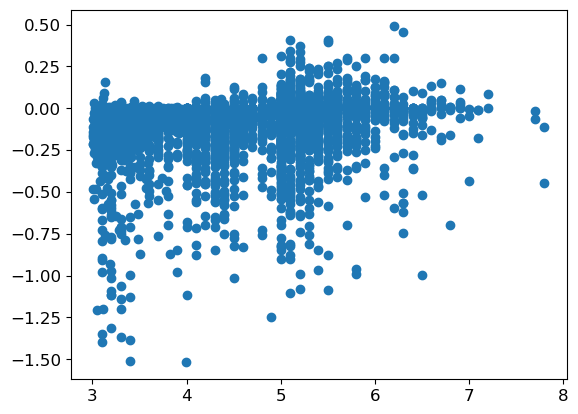

In [36]:
plt.scatter(x_tp_04_01, y_tp_04_01-y_tp_03)

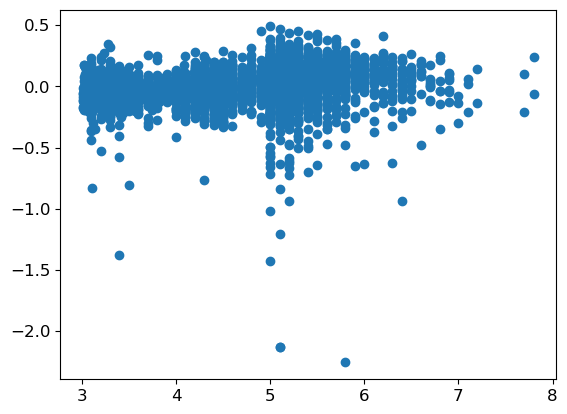

In [37]:
plt.scatter(x_tc_04_01, y_tc_04_01-y_tc_03)

In [38]:
y_iv2_03

array([-5.40891628, -6.52388991, -3.445609  , ..., -7.07404073,
       -8.53942788, -5.6738811 ])

In [43]:
compare_true_shifted

,level_0_03,index_03,eq_id,eq_mag_03,eq_mag_type_03,eq_time_03,eq_loc_03,tp_max_03,tp_max_stations_03,tc_03,...,tc_04_01,tc_stations_04_01,iv2_04_01,iv2_distances_04_01,iv2_stations_04_01,pgd_04_01,pgd_distances_04_01,pgd_stations_04_01,distance_dict_04_01,azimuth_dict_04_01
0,0,0,2110129,5.00,MW,20050131_173151,"(-41.6009, 175.838, 19.9)",[0.4606962267009133],[NZ.MRZ.10],[0.7684089258967769],...,[0.607730108740278],[NZ.MRZ.10],[],[],[],[2.0706273025513535e-06],[106.68083076278864 km],[NZ.MRZ.10],"{'IU.SNZO.00': 102.08314562572458, 'NZ.BFZ.10'...","{'IU.SNZO.00': -71.39814996005346, 'NZ.BFZ.10'..."
1,1,0,2011699,5.30,MW,20050120_185630,"(-41.1222, 174.9773, 39.7)",[0.42668707984997223],[NZ.MRZ.10],[0.5625841278209616],...,[0.4566053337328034],[NZ.MRZ.10],[1.2752179273648749e-09],[72.07969998851411 km],[NZ.MRZ.10],[6.908218325367025e-06],[72.07969998851411 km],[NZ.MRZ.10],"{'IU.SNZO.00': 50.273212837431664, 'NZ.MRZ.10'...","{'IU.SNZO.00': -132.33427803852754, 'NZ.MRZ.10..."
2,2,0,2000953,5.00,MW,20050118_092558,"(-41.5413, 175.8527, 21.0)",[1.751189476872014],[NZ.MRZ.10],[0.4975850948693986],...,[0.6465452111464143],[NZ.MRZ.10],[],[],[],[2.5852697702584372e-06],[100.4879719628321 km],[NZ.MRZ.10],"{'IU.SNZO.00': 101.6008496163856, 'NZ.BFZ.10':...","{'IU.SNZO.00': -75.26438587458226, 'NZ.BFZ.10'..."
3,3,0,2000808,5.20,MW,20050118_083600,"(-41.6055, 175.8911, 9.2)","[1.5581815100077676, 1.1656885463505522]","[NZ.BFZ.10, NZ.MRZ.10]","[0.913468218414827, 3.527110366929211]",...,"[0.3023887211558064, 3.12384034201095]","[NZ.BFZ.10, NZ.MRZ.10]",[],[],[],"[2.2358515086123425e-06, 1.5862808022453232e-06]","[107.05746146962363 km, 108.1752118389166 km]","[NZ.BFZ.10, NZ.MRZ.10]","{'IU.SNZO.00': 104.89522924441958, 'NZ.BFZ.10'...","{'IU.SNZO.00': -71.94018844036243, 'NZ.BFZ.10'..."
4,4,0,1947713,5.00,MW,20050204_091538,"(-37.922, -73.3985, 22.8)","[0.4191753547986052, 0.40940317990063774, 0.27...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[0.29907925737335306, 0.24328713385763964, 0.2...",...,"[0.4886743837534872, 0.24558623100073626, 0.25...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[2.1006395211162764e-10, 3.5339611820572935e-0...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A404., ZW.A4...","[3.710399506895767e-06, 8.9538606473997e-05, 3...","[46.52436835522224 km, 45.99021789372439 km, 3...","[ZW.A401., ZW.A402., ZW.A403., ZW.A406., ZW.A4...","{'ZW.A401.': 51.769043605734154, 'ZW.A402.': 5...","{'ZW.A401.': 175.7254064462551, 'ZW.A402.': -1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4574,2319,0,11139880,5.30,Mww,20191101_152412,"(11.5712, -86.7909, 50.02)","[1.5794086189218965, 0.9599298495581294, 1.528...","[NU.CNGN., NU.CRIN., NU.HERN., NU.NANN.]","[2.478222314458216, 1.3037756084755636, 1.4971...",...,"[4.459328843286462, 0.5220044753998828]","[NU.CNGN., NU.CRIN.]",[],[],[],[1.034100938462729e-05],[128.0167604106423 km],[NU.CRIN.],"{'NU.CNGN.': 114.49352330505805, 'NU.CRIN.': 1...","{'NU.CNGN.': 5.547608296218749, 'NU.CRIN.': -1..."
4575,2319,0,11139880,5.30,Mww,20191101_152412,"(11.5712, -86.7909, 50.02)","[1.5794086189218965, 0.9599298495581294, 1.528...","[NU.CNGN., NU.CRIN., NU.HERN., NU.NANN.]","[2.478222314458216, 1.3037756084755636, 1.4971...",...,"[4.459328843286462, 0.5220044753998828, 1.9156...","[NU.CNGN., NU.CRIN., NU.HERN., NU.NANN.]",[1.6879310245793001e-07],[83.56438721336707 km],[NU.NANN.],"[1.034100938462729e-05, 0.00024555964119936857]","[128.0167604106423 km, 83.56438721336707 km]","[NU.CRIN., NU.NANN.]","{'NU.CARN.00': 153.21529323404573, 'NU.CNGN.':...","{'NU.CARN.00': 107.03038511884024, 'NU.CNGN.':..."
4576,2320,0,11139830,3.55,Mw,20191101_093317,"(36.568833, -117.976, 10.79)","[0.7219045391356451, 0.222702389051299, 0.3741...","[CI.CGO., CI.CWC., NN.DSP., CI.FUR., CI.GRA., ...","[0.2243993537991736, 0.1144002160947817, 0.231...",...,"[0.20673011325378782, 0.11155062446066781, 0.2...","[CI.CGO., C

In [46]:
row['iv2_03']

[None,
 None,
 -5.706000190828054e-11,
 2.6464990175950932e-09,
 1.0166809502694881e-07]

In [49]:
masked

masked_array(data=[None, None, -5.706000190828054e-11,
                   2.6464990175950932e-09, 1.0166809502694881e-07],
             mask=False,
       fill_value='?',
            dtype=object)

In [56]:
np.where(row['iv2_03']==None)

/tmp/ipykernel_1657073/4161348988.py:1: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  np.where(row['iv2_03']==None)


(array([], dtype=int64),)

In [52]:
x_iv2_04_01 = []
x_iv2_03 = []
y_iv2_04_01 = []
y_iv2_03 = []
for i, row in compare_true_shifted.iterrows():
	x_iv2_04_01.append(row['eq_mag_04_01'])
	masked = ma.masked_where(row['iv2_04_01'] == None, row['iv2_04_01'])
	y_iv2_04_01.append(np.mean(masked))
	x_iv2_03.append(row['eq_mag_03'])
	masked = ma.masked_where(row['iv2_03'] == None, row['iv2_03'])
	y_iv2_03.append(np.mean(masked))




/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc6/lib/python3.12/site-packages/numpy/ma/core.py:5334: RuntimeWarning: Mean of empty slice.
  result = super().mean(axis=axis, dtype=dtype, **kwargs)[()]
/home/earthquakes1/software/Ubuntu/anaconda3/envs/rlc6/lib/python3.12/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


TypeError: unsupported operand type(s) for +: 'NoneType' and 'NoneType'

In [39]:
plt.scatter(x_iv2_04_01, y_iv2_04_01-y_iv2_03)

ValueError: operands could not be broadcast together with shapes (19898,) (19675,) 

In [ ]:
# import os
# import glob

# # Set the root directory you want to search from
# root_dir = "."

# # Pattern to match the specific files
# #pattern = "eq_object_06s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl"
# list_of_patterns = ["eq_object_06s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl",
#                    "eq_object_11s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl",
#                    "eq_object_41s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl",
#                    "eq_object_04s_snr_20_blank_neg_01_reviews_snr_20_delay.pkl"]
# for pattern in list_of_patterns:
#     # Recursively find all matching files
#     for filepath in glob.iglob(f"{root_dir}/**/{pattern}", recursive=True):
#         # Create the new filename
#         new_filename = filepath.replace("blank_neg_01", "blank_01")
        
#         # Rename the file
#         os.rename(filepath, new_filename)
#         print(f"Renamed: {filepath} -> {new_filename}")
